Importing dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset Loading and Path Configuration

In [ ]:
# =========================
# BASE PATH
# =========================
base_path = '/content/drive/MyDrive/IDRID/B-2'

# Image folder
images_path = os.path.join(base_path, '1. Original Images', 'a. Training Set')

# Correct CSV path
labels_path = os.path.join(base_path,'2. Groundtruths', 'a. IDRiD_Disease Grading_Training Labels.csv')

Data Cleaning and Label Preprocessing

In [ ]:
# =========================
# LOAD LABEL FILE
# =========================

df = pd.read_csv(labels_path)

print("Original class distribution:")
print(df['Retinopathy grade'].value_counts())

Original class distribution:
Retinopathy grade
2    136
0    134
3     74
4     49
1     20
Name: count, dtype: int64


In [ ]:
# Remove class 1
df = df[df['Retinopathy grade'] != 1]

print("\nRemaining class distribution:")
print(df['Retinopathy grade'].value_counts())


Remaining class distribution:
Retinopathy grade
2    136
0    134
3     74
4     49
Name: count, dtype: int64


In [ ]:
# Re-map labels
df['Retinopathy grade'] = df['Retinopathy grade'].replace({
    2:1,
    3:2,
    4:3
})

print("\nNew labels:")
print(df['Retinopathy grade'].value_counts())


New labels:
Retinopathy grade
1    136
0    134
2     74
3     49
Name: count, dtype: int64


In [ ]:
# Remove unwanted columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Clean column names
df.columns = df.columns.str.strip()

print("\nColumns after cleaning:")
print(df.columns)

print("\nSample Data:")
print(df.head())


Columns after cleaning:
Index(['Image name', 'Retinopathy grade', 'Risk of macular edema'], dtype='object')

Sample Data:
  Image name  Retinopathy grade  Risk of macular edema
0  IDRiD_001                  2                      2
1  IDRiD_002                  2                      2
2  IDRiD_003                  1                      2
3  IDRiD_004                  2                      2
4  IDRiD_005                  3                      0


Exploratory Data Analysis (EDA)

In [ ]:
# =========================
# VISUALIZATION FUNCTION
# =========================
def visualize_samples(df, img_dir, num_samples=5):

    plt.figure(figsize=(15,5))

    for i in range(num_samples):

        img_name = df.iloc[i]['Image name']
        dr_grade = df.iloc[i]['Retinopathy grade']
        dme_grade = df.iloc[i]['Risk of macular edema']

        img_path = os.path.join(img_dir, img_name + ".jpg")

        img = Image.open(img_path)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"DR:{dr_grade} | DME:{dme_grade}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


Image Preprocessing

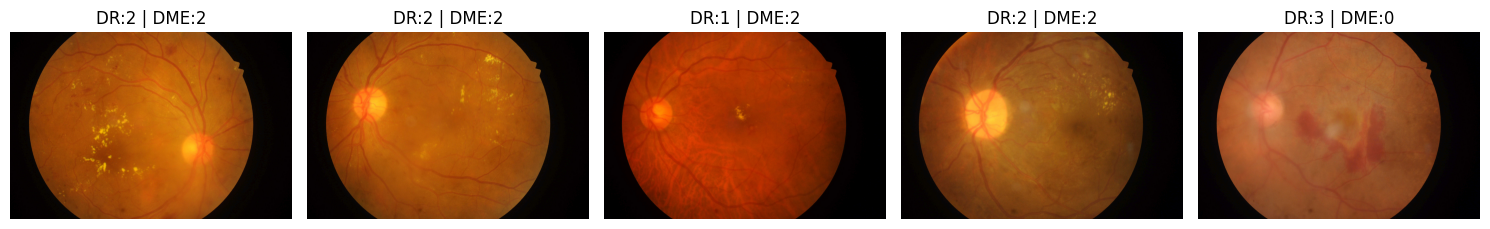

In [ ]:
# =========================
# SHOW SAMPLE IMAGES
# =========================
images_path = "/content/drive/MyDrive/IDRID/B-2/1. Original Images/a. Training Set"

visualize_samples(df, images_path, num_samples=5)

**Check Class Distribution**

Class Distribution:
Retinopathy grade
0    134
1    136
2     74
3     49
Name: count, dtype: int64


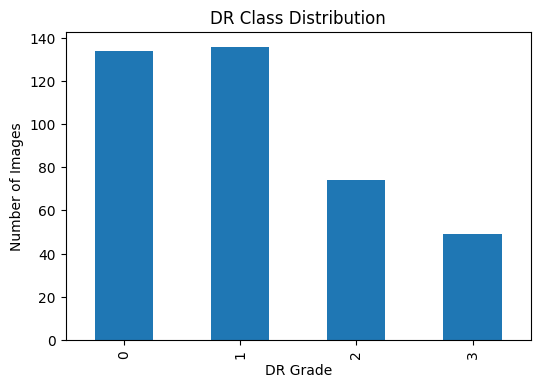

In [ ]:
# Count DR grades
class_counts = df['Retinopathy grade'].value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

# Plot
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title("DR Class Distribution")
plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.show()

Data Augmentation

In [ ]:
import cv2
import numpy as np
import os
from tensorflow.keras.applications.xception import preprocess_input

def preprocess_image(img_path, size=(299, 299)):

    # Handle missing files and alternative extensions
    if not os.path.exists(img_path):
        base, _ = os.path.splitext(img_path)
        for ext in ['.jpg', '.JPG', '.jpeg', '.png']:
            alt_path = base + ext
            if os.path.exists(alt_path):
                img_path = alt_path
                break

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image at path: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)

    img = img.astype(np.float32)
    img = preprocess_input(img)

    return img

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

In [ ]:
import random

def augment_image(img):

    # Random horizontal flip
    if random.random() < 0.5:
        img = np.fliplr(img)

    # Random vertical flip
    if random.random() < 0.3:
        img = np.flipud(img)

    # Random rotation
    if random.random() < 0.5:
        angle = random.randint(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        img = cv2.warpAffine(img, M, (w, h))

    # Random brightness adjustment
    if random.random() < 0.5:
        factor = random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 1)

    return img

Train–Validation Dataset Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Retinopathy grade'],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 314
Validation size: 79


Custom Data Generator

In [ ]:
from tensorflow.keras.utils import Sequence
import os
import numpy as np

class DRDataGenerator(Sequence):

    def __init__(self, dataframe, img_dir, batch_size=16, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return len(self.df) // self.batch_size

    def __getitem__(self, index):

        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        images = []
        labels = []

        for i in batch_indexes:
            img_name = self.df.iloc[i]['Image name']
            label = self.df.iloc[i]['Retinopathy grade']

            img_path = os.path.join(self.img_dir, img_name + ".jpg")

            img = preprocess_image(img_path)

            # Apply augmentation ONLY for training
            if self.shuffle:
                img = augment_image(img)

            images.append(img)
            labels.append(label)

        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

Custom Data Generator

In [ ]:
train_gen = DRDataGenerator(train_df, images_path, batch_size=32, shuffle=True)
val_gen   = DRDataGenerator(val_df, images_path, batch_size=32, shuffle=False)

Model Architecture – Hybrid Xception + BiLSTM

In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load Xception without top layer (Xception + BiLSTM hybrid)
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(299,299,3)
)

# Unfreeze top layers so the model can adapt to medical images
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

# Get feature maps
x = base_model.output  # shape: (None, 10, 10, 2048)

# Reshape feature map to sequence
x = layers.Reshape((-1, x.shape[-1]))(x)
# Now shape: (None, time_steps, 2048)

# BiLSTM layer
x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=False)
)(x)

# Fully connected layers
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output layer (4 classes)
output = layers.Dense(4, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_12[0][0]    

 Total params: 23,157,548 (88.34 MB)

 Trainable params: 19,306,300 (73.65 MB)

 Non-trainable params: 3,851,248 (14.69 MB)

Model Training

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import numpy as np

# =========================================
# 1. Compute (softened) class weights
# =========================================
classes = np.unique(train_df['Retinopathy grade'])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['Retinopathy grade'].values
)

class_weights = dict(zip(classes, weights))

# soften weights
class_weights_sqrt = {k: float(v) ** 0.5 for k, v in class_weights.items()}

# =========================================
# 2. Compile hybrid model
# =========================================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# 3. Learning-rate scheduler
# =========================================
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# =========================================
# 4. Train HYBRID (Xception + BiLSTM)
# =========================================
history_hybrid = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights_sqrt,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 459s 47s/step - accuracy: 0.2986 - loss: 1.3564 - val_accuracy: 0.4219 - val_loss: 1.3644 - learning_rate: 1.0000e-04
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 382s 42s/step - accuracy: 0.3889 - loss: 1.3321 - val_accuracy: 0.4531 - val_loss: 1.3405 - learning_rate: 1.0000e-04
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 374s 42s/step - accuracy: 0.4375 - loss: 1.2753 - val_accuracy: 0.5781 - val_loss: 1.2409 - learning_rate: 1.0000e-04
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 391s 44s/step - accuracy: 0.5035 - loss: 1.1683 - val_accuracy: 0.6562 - val_loss: 1.1551 - learning_rate: 1.0000e-04
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 390s 44s/step - accuracy: 0.5208 - loss: 1.0613 - val_accuracy: 0.6406 - val_loss: 0.9582 - learning_rate: 1.0000e-04
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 378s 42s/step - accuracy: 0.5347 - loss: 1.0515 - val_accuracy: 0.5000 - val_loss: 1.1091 - learning_rate: 1.0000e-04
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 386s 43s/step - accuracy: 0.6111 - loss:

Model Evaluation

In [ ]:
print("Final Training Accuracy:", history_hybrid.history['accuracy'][-1])
print("Final Validation Accuracy:", history_hybrid.history['val_accuracy'][-1])

Final Training Accuracy: 0.9618055820465088
Final Validation Accuracy: 0.6875


Predictions

In [ ]:
import numpy as np

y_true = []
for i in range(len(val_gen)):
    _, labels = val_gen[i]
    y_true.extend(labels)

y_true = np.array(y_true)

y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 36s 14s/step


**Confusion Matrix**

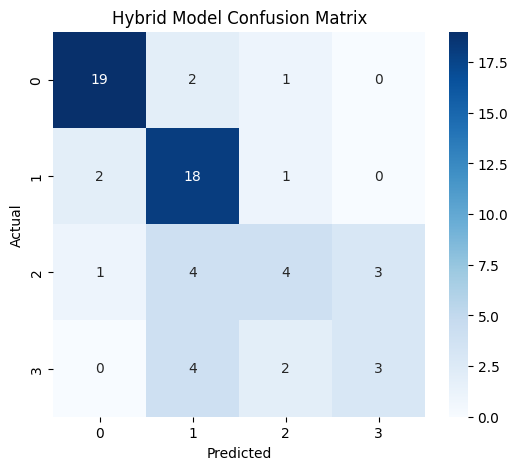

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Hybrid Model Confusion Matrix')
plt.show()

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8636    0.8636    0.8636        22
           1     0.6429    0.8571    0.7347        21
           2     0.5000    0.3333    0.4000        12
           3     0.5000    0.3333    0.4000         9

    accuracy                         0.6875        64
   macro avg     0.6266    0.5969    0.5996        64
weighted avg     0.6719    0.6875    0.6692        64



AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import to_categorical

y_true_cat = to_categorical(y_true, num_classes=4)

auc = roc_auc_score(y_true_cat, y_pred_probs, multi_class='ovr')

print("Hybrid Model AUC:", auc)

Hybrid Model AUC: 0.8956099133424715


In [ ]:
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 34s 14s/step


In [ ]:
import pandas as pd

# Create comparison dataframe
results_df = pd.DataFrame({
    "Actual Label": y_true,
    "Predicted Label": y_pred
})

# Show first 20 predictions
print(results_df.head(20))

    Actual Label  Predicted Label
0              2                3
1              0                0
2              1                0
3              3                2
4              2                2
5              1                1
6              1                1
7              0                0
8              2                3
9              1                1
10             1                2
11             0                0
12             1                1
13             2                2
14             0                0
15             1                0
16             0                0
17             0                1
18             0                0
19             0                0


Actual VS Predicted

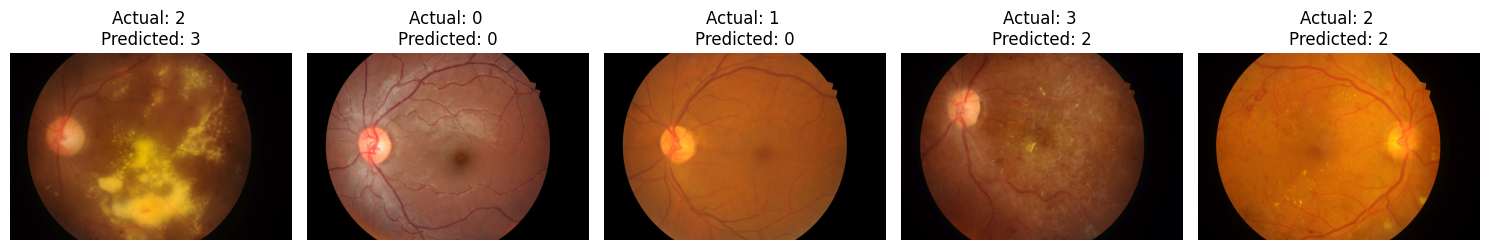

In [ ]:
import matplotlib.pyplot as plt

def show_predictions(generator, y_true, y_pred, img_dir, num_images=5):

    plt.figure(figsize=(15,6))

    for i in range(num_images):

        img_name = generator.df.iloc[i]['Image name']
        img_path = os.path.join(img_dir, img_name + ".jpg")

        img = Image.open(img_path)

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"Actual: {y_true[i]} \nPredicted: {y_pred[i]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call function
show_predictions(val_gen, y_true, y_pred, images_path, num_images=5)